##Análise

A análise dos principais clientes permite identificar o nível de concentração da receita.

Foram avaliados:

- ranking dos clientes por receita;
- participação percentual individual;
- participação acumulada dos principais clientes;
- concentração da receita entre os cinco maiores clientes.

Essas informações auxiliam na identificação de dependência comercial e oportunidades para diversificação da carteira de clientes.

Os resultados desta análise poderão ser utilizados futuramente para estudos como Curva ABC e análise de retenção.

In [76]:
top5_share = (
    top_customers
    .head(5)["ParticipacaoPercentual"]
    .sum()
)

top5_share

np.float64(52.89832087539674)

In [ ]:
best_customer = top_customers.iloc[0]

best_customer

CustomerID                      29818
Cliente                   Roger Harui
QuantidadePedidos                  12
ReceitaTotal               989,184.08
ParticipacaoPercentual          11.07
Name: 0, dtype: object


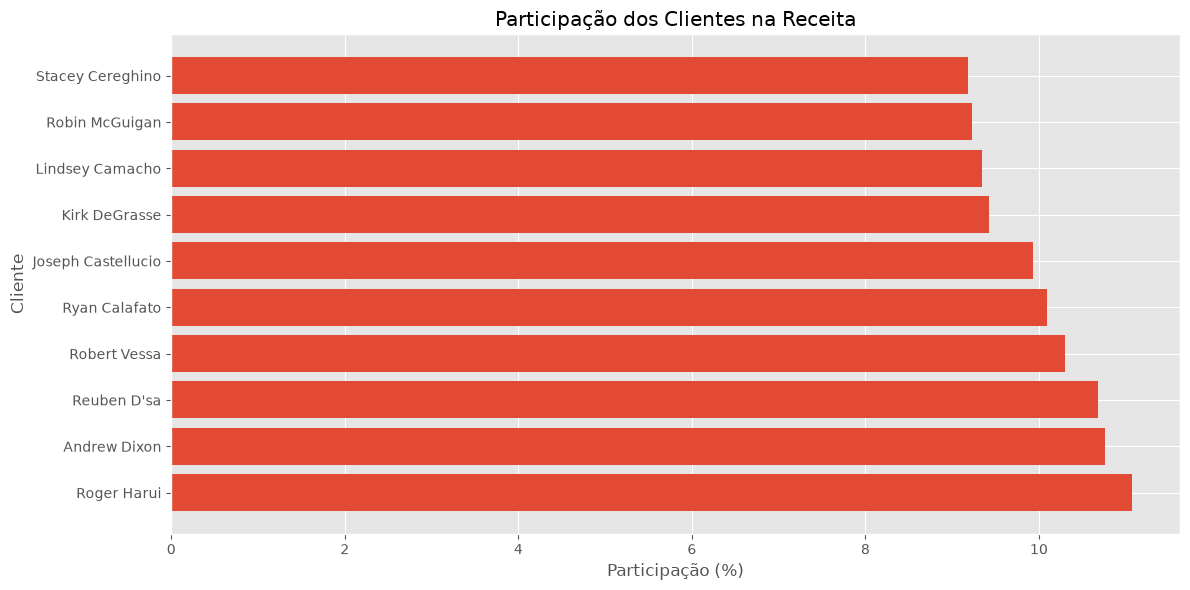

In [73]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_customers["Cliente"],
    top_customers["ParticipacaoPercentual"]
)

plt.title("Participação dos Clientes na Receita")

plt.xlabel("Participação (%)")

plt.ylabel("Cliente")

plt.tight_layout()

plt.show()

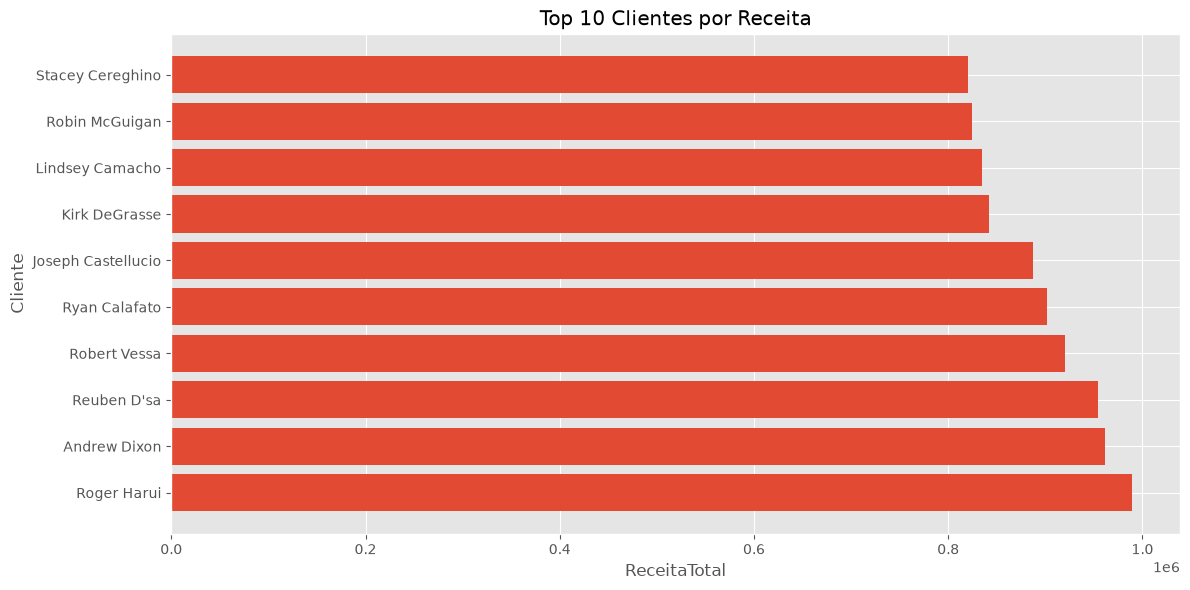

In [72]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_customers["Cliente"],
    top_customers["ReceitaTotal"]
)

plt.title("Top 10 Clientes por Receita")

plt.xlabel("ReceitaTotal")

plt.ylabel("Cliente")

plt.tight_layout()

plt.show()

In [70]:
top_customers[
    [
        top_customers.columns[0],
        "ReceitaTotal",
        "ParticipacaoPercentual"
    ]
]

,CustomerID,ReceitaTotal,ParticipacaoPercentual
0,29818,"989,184.08",11.07
1,29715,"961,675.86",10.76
2,29722,"954,021.92",10.68
3,30117,"919,801.82",10.30
4,29614,"901,346.86",10.09
5,29639,"887,090.41",9.93
6,29701,"841,866.55",9.42
7,29617,"834,475.93",9.34
8,29994,"824,331.77",9.23
9,29646,"820,383.55",9.18


In [68]:
receita_top10 = top_customers["ReceitaTotal"].sum()

receita_top10

np.float64(8934178.7446)

In [66]:
top_customers["ParticipacaoPercentual"] = (
    top_customers["ReceitaTotal"]
    / top_customers["ReceitaTotal"].sum()
) * 100
top_customers

,CustomerID,Cliente,QuantidadePedidos,ReceitaTotal,ParticipacaoPercentual
0,29818,Roger Harui,12,"989,184.08",11.07
1,29715,Andrew Dixon,12,"961,675.86",10.76
2,29722,Reuben D'sa,12,"954,021.92",10.68
3,30117,Robert Vessa,12,"919,801.82",10.30
4,29614,Ryan Calafato,12,"901,346.86",10.09
5,29639,Joseph Castellucio,12,"887,090.41",9.93
6,29701,Kirk DeGrasse,8,"841,866.55",9.42
7,29617,Lindsey Camacho,12,"834,475.93",9.34
8,29994,Robin McGuigan,12,"824,331.77",9.23
9,29646,Stacey Cereghino,12,"820,383.55",9.18


In [63]:
top_customers.describe(include="all")

,CustomerID,Cliente,QuantidadePedidos,ReceitaTotal
count,10.00,10,10.00,10.00
unique,NaN,10,NaN,NaN
top,NaN,Roger Harui,NaN,NaN
freq,NaN,1,NaN,NaN
mean,"29,758.30",NaN,11.60,"893,417.87"
std,170.58,NaN,1.26,"61,950.50"
min,"29,614.00",NaN,8.00,"820,383.55"
25%,"29,640.75",NaN,12.00,"836,323.58"
50%,"29,708.00",NaN,12.00,"894,218.63"
75%,"29,794.00",NaN,12.00,"945,466.90"


In [62]:
top_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10 non-null     int64  
 1   Cliente            10 non-null     str    
 2   QuantidadePedidos  10 non-null     int64  
 3   ReceitaTotal       10 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 587.0 bytes


In [61]:
print(top_customers.columns.tolist())

['CustomerID', 'Cliente', 'QuantidadePedidos', 'ReceitaTotal']


In [60]:
top_customers = run_query("05_top_customers.sql")

top_customers.head

<bound method NDFrame.head of    CustomerID             Cliente  QuantidadePedidos  ReceitaTotal
0       29818         Roger Harui                 12    989,184.08
1       29715        Andrew Dixon                 12    961,675.86
2       29722         Reuben D'sa                 12    954,021.92
3       30117        Robert Vessa                 12    919,801.82
4       29614       Ryan Calafato                 12    901,346.86
5       29639  Joseph Castellucio                 12    887,090.41
6       29701       Kirk DeGrasse                  8    841,866.55
7       29617     Lindsey Camacho                 12    834,475.93
8       29994      Robin McGuigan                 12    824,331.77
9       29646    Stacey Cereghino                 12    820,383.55>

##Análise

A evolução da receita permite identificar o comportamento financeiro da empresa ao longo dos anos.

Nesta análise foram observados:

- evolução anual da receita;
- melhor ano em faturamento;
- menor faturamento registrado;
- crescimento percentual entre períodos consecutivos.

Essas informações serão reutilizadas posteriormente no dashboard para construção do gráfico de evolução temporal e dos indicadores executivos.

In [42]:
print(
    f"Maior crescimento percentual: "
    f"{best_growth['Ano']} "
    f"({best_growth['CrescimentoPercentual']:.2f}%)"
)

Maior crescimento percentual: 2012.0 (166.15%)


In [41]:
growth = sales_over_time.dropna()

best_growth = growth.loc[
    growth["CrescimentoPercentual"].idxmax()
]

best_growth

Ano                          2,012.00
Receita                 37,675,700.31
CrescimentoPercentual          166.15
Name: 1, dtype: float64

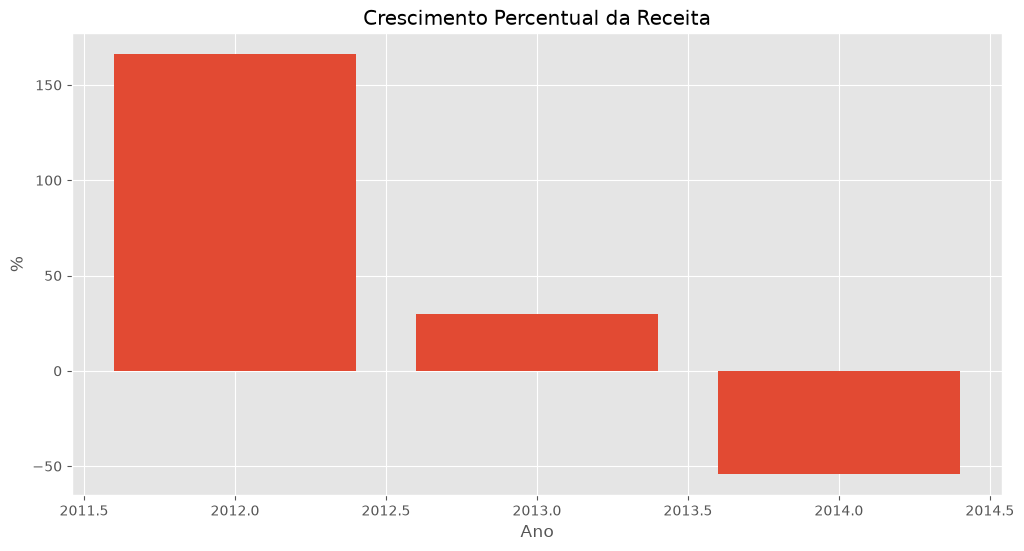

In [40]:
plt.figure(figsize=(12, 6))

plt.bar(
    sales_over_time["Ano"],
    sales_over_time["CrescimentoPercentual"]
)

plt.title("Crescimento Percentual da Receita")

plt.xlabel("Ano")

plt.ylabel("%")

plt.show()

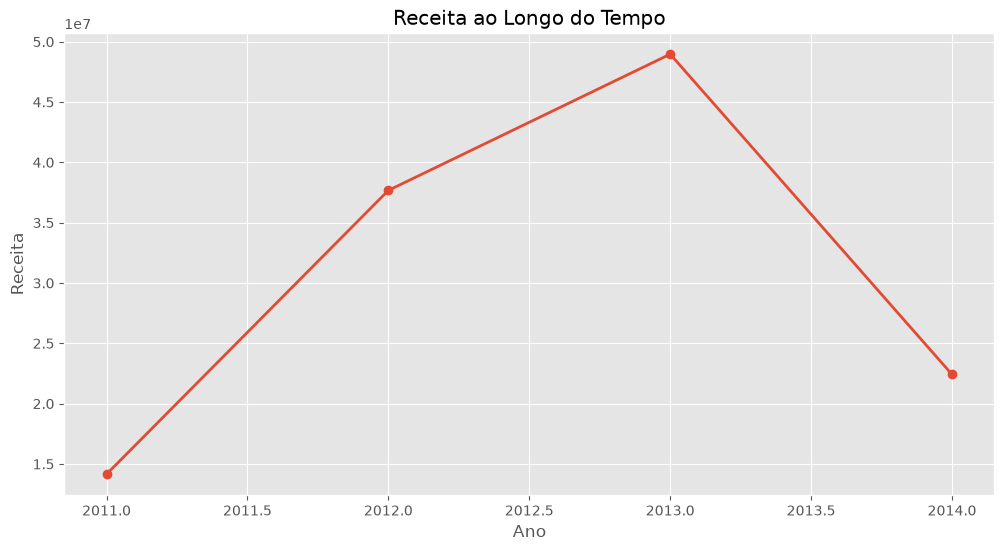

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    sales_over_time["Ano"],
    sales_over_time["Receita"],
    marker="o",
    linewidth=2
)

plt.title("Receita ao Longo do Tempo")

plt.xlabel("Ano")

plt.ylabel("Receita")

plt.grid(True)

plt.show()

In [38]:
print(
    f"Maior receita: {best_year['Ano']} - "
    f"R$ {best_year['Receita']:,.2f}"
)

print()

print(
    f"Menor receita: {worst_year['Ano']} - "
    f"R$ {worst_year['Receita']:,.2f}"
)

Maior receita: 2013.0 - R$ 48,965,887.96

Menor receita: 2011.0 - R$ 14,155,699.53


In [37]:
worst_year = sales_over_time.loc[
    sales_over_time["Receita"].idxmin()
]

worst_year

Ano                          2,011.00
Receita                 14,155,699.53
CrescimentoPercentual             NaN
Name: 0, dtype: float64

In [36]:
best_year = sales_over_time.loc[
    sales_over_time["Receita"].idxmax()
]

best_year

Ano                          2,013.00
Receita                 48,965,887.96
CrescimentoPercentual           29.97
Name: 2, dtype: float64

In [35]:
sales_over_time

,Ano,Receita,CrescimentoPercentual
0,2011,"14,155,699.53",NaN
1,2012,"37,675,700.31",166.15
2,2013,"48,965,887.96",29.97
3,2014,"22,419,498.32",-54.21


In [34]:
sales_over_time["CrescimentoPercentual"] = (
    sales_over_time["Receita"].pct_change() * 100
)

In [33]:
sales_over_time.describe()

,Ano,Receita
count,4.00,4.00
mean,"2,012.50","30,804,196.53"
std,1.29,"15,540,701.58"
min,"2,011.00","14,155,699.53"
25%,"2,011.75","20,353,548.62"
50%,"2,012.50","30,047,599.31"
75%,"2,013.25","40,498,247.22"
max,"2,014.00","48,965,887.96"


In [32]:
sales_over_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      4 non-null      int64  
 1   Receita  4 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 196.0 bytes


In [31]:
print(sales_over_time.columns.tolist())

['Ano', 'Receita']


In [30]:
sales_over_time = run_query("04_sales_over_time.sql")

sales_over_time

,Ano,Receita
0,2011,"14,155,699.53"
1,2012,"37,675,700.31"
2,2013,"48,965,887.96"
3,2014,"22,419,498.32"


##Análise

O Ticket Médio representa o valor médio gasto por pedido realizado.

Esse indicador auxilia na avaliação do comportamento de compra dos clientes e será reutilizado posteriormente no dashboard.

In [29]:
print(f"Ticket Médio: R$ {ticket:,.2f}")

Ticket Médio: R$ 3,916.00


In [28]:
ticket = average_ticket.loc[0, "TicketMedio"]

ticket

np.float64(3915.9951)

In [27]:
average_ticket = run_query("03_average_ticket.sql")
average_ticket

,TicketMedio
0,"3,916.00"


##Análise

Este indicador representa a quantidade total de pedidos registrados na base de dados.

Em conjunto com a Receita Total e o Ticket Médio, ele compõe os principais indicadores executivos do projeto.

In [26]:
print(f"Total de Pedidos: {total_orders}")

Total de Pedidos: 31465


In [25]:
total_orders = orders.loc[0, "TotalPedidos"]

total_orders

np.int64(31465)

In [24]:
orders = run_query("02_orders.sql")
orders

,TotalPedidos
0,31465


##Análise

A consulta retorna o faturamento acumulado considerando todas as vendas existentes na base de dados.

Este indicador será utilizado posteriormente no dashboard como um dos KPIs principais.

In [23]:
print(f"Receita Total: R$ {total_revenue:,.2f}")

Receita Total: R$ 123,216,786.12


In [22]:
total_revenue = revenue.loc[0, "ReceitaTotal"]

total_revenue

np.float64(123216786.1159)

In [21]:
revenue = run_query("01_revenue.sql")
revenue

,ReceitaTotal
0,"123,216,786.12"


In [20]:
run_query

<function query_executor.run_query(filename: str)>

In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("ggplot")

In [18]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

from query_executor import run_query

#Business Analysis

Este notebook apresenta a análise de negócio do projeto Sales Analytics Platform.

As análises são realizadas através das consultas SQL armazenadas em:

sql/business/

Métricas analisadas:

- Receita Total
- Número de Pedidos
- Ticket Médio
- Receita ao longo do tempo
- Top Clientes
- Top Produtos